# Final Project — Bootcamp Data Science
## Decision Intelligence: Prediksi Nasabah Berlangganan Deposito Berjangka (Bank Marketing)

**Tema:** Finance & Banking
**Dataset:** `Dataset_10_bank.csv` (Bank Marketing Dataset)
**Tim:** *(isi nama tim & anggota di sini)*

> **v2 — revisi berdasarkan catatan mentor:** setiap keputusan preprocessing dan setiap insight sekarang disertai bukti/visualisasi kuantitatif, ditambahkan hyperparameter tuning untuk meningkatkan performa model, dan feature importance dilengkapi insight per fitur.

Notebook ini mengikuti alur wajib Final Project ISE Academy x Hacktiv8 x Avalon:
1. Latar Belakang Bisnis & Business Question
2. Import Library & Load Data
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing (dengan justifikasi berbasis bukti)
5. Modeling (Baseline) & Hyperparameter Tuning
6. Evaluasi Model
7. Feature Importance & Insight
8. Insight & Rekomendasi Keputusan Bisnis


## 1. Latar Belakang Bisnis

Bank menjalankan kampanye **telemarketing** untuk menawarkan produk **deposito berjangka (term deposit)** kepada nasabah. Setiap panggilan telemarketing membutuhkan biaya (waktu agen, biaya komunikasi), sementara tidak semua nasabah yang dihubungi akan tertarik berlangganan.

Jika bank dapat **memprediksi terlebih dahulu nasabah mana yang punya peluang besar untuk berlangganan deposito**, maka tim marketing bisa:
- Memprioritaskan nasabah dengan peluang konversi tinggi
- Mengurangi biaya kampanye (jumlah panggilan yang sia-sia)
- Meningkatkan efisiensi dan *conversion rate* kampanye

## 2. Pertanyaan Bisnis (Business Question)

> **"Berdasarkan profil demografis dan riwayat kontak kampanye sebelumnya, apakah kita bisa memprediksi kemungkinan seorang nasabah akan berlangganan deposito berjangka, sehingga tim marketing bisa menargetkan kampanye secara lebih efisien?"**

Ini adalah kasus **klasifikasi biner** dengan target `deposit` (`yes` / `no`).

**Catatan penting soal fitur `duration`:** kolom `duration` (lama panggilan telepon dalam detik) baru diketahui **setelah** panggilan selesai — bank tidak tahu berapa lama sebuah panggilan akan berlangsung *sebelum* menelepon. Karena itu, `duration` **tidak realistis dipakai untuk model targeting pra-panggilan** (data leakage). Kita akan:
- Membangun **Model Utama (tanpa `duration`)** → dipakai untuk rekomendasi bisnis (menentukan siapa yang layak ditelepon)
- Membangun **Model Pembanding (dengan `duration`)** → hanya untuk menunjukkan seberapa besar pengaruh leakage tersebut terhadap performa model (insight tambahan untuk laporan), dibahas di Bagian 8


## 3. Import Library & Load Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

print("Library berhasil di-import.")

Library berhasil di-import.


In [ ]:
# Jika dijalankan di Google Colab dan file belum ada, upload manual.
import os

file_name = "Dataset_10_bank.csv"

if not os.path.exists(file_name):
    try:
        from google.colab import files
        print("Silakan upload file Dataset_10_bank.csv")
        uploaded = files.upload()
        file_name = next(iter(uploaded))
    except ImportError:
        raise FileNotFoundError(
            "Dataset_10_bank.csv tidak ditemukan. "
            "Pastikan file berada di folder yang sama dengan notebook."
        )

df = pd.read_csv(file_name)
print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])
df.head()

Jumlah baris : 11162
Jumlah kolom : 17


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


## 4. Exploratory Data Analysis (EDA)

### 4.1 Struktur & Kualitas Data

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  str  
 2   marital    11162 non-null  str  
 3   education  11162 non-null  str  
 4   default    11162 non-null  str  
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  str  
 7   loan       11162 non-null  str  
 8   contact    11162 non-null  str  
 9   day        11162 non-null  int64
 10  month      11162 non-null  str  
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-null  int64
 15  poutcome   11162 non-null  str  
 16  deposit    11162 non-null  str  
dtypes: int64(7), str(10)
memory usage: 1.4 MB


In [ ]:
missing_summary = pd.DataFrame({
    "Jumlah Missing": df.isnull().sum(),
    "Persentase (%)": (df.isnull().mean() * 100).round(2)
})
missing_summary

,Jumlah Missing,Persentase (%)
age,0,0.0
job,0,0.0
marital,0,0.0
education,0,0.0
default,0,0.0
balance,0,0.0
housing,0,0.0
loan,0,0.0
contact,0,0.0
day,0,0.0


In [ ]:
print("Jumlah baris duplikat:", df.duplicated().sum())

Jumlah baris duplikat: 0


In [ ]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


**Insight:** Dataset tidak memiliki missing value (`NaN`) maupun duplikat secara eksplisit. Namun beberapa kolom kategorikal menyimpan nilai `"unknown"` yang secara fungsi berperan sebagai *missing value* tersamar — ini kita investigasi lebih dalam di bagian 4.6 sebelum diputuskan bagaimana penanganannya.

### 4.2 Distribusi Target (`deposit`)

deposit
no     5873
yes    5289
Name: count, dtype: int64

deposit
no     52.62
yes    47.38
Name: proportion, dtype: float64


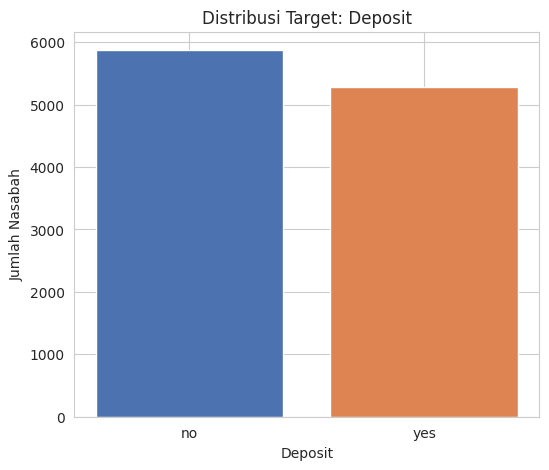

In [ ]:
target_counts = df["deposit"].value_counts()
target_pct = df["deposit"].value_counts(normalize=True) * 100

print(target_counts)
print()
print(target_pct.round(2))

plt.figure(figsize=(6, 5))
plt.bar(target_counts.index, target_counts.values, color=["#4C72B0", "#DD8452"])
plt.title("Distribusi Target: Deposit")
plt.xlabel("Deposit")
plt.ylabel("Jumlah Nasabah")
plt.show()

**Insight:** Distribusi kelas cukup seimbang (sekitar 53% `no` vs 47% `yes`), sehingga metrik accuracy masih cukup representatif, namun kita tetap akan melihat precision, recall, dan F1-score agar evaluasi lebih lengkap.

### 4.3 Analisis Fitur Numerik

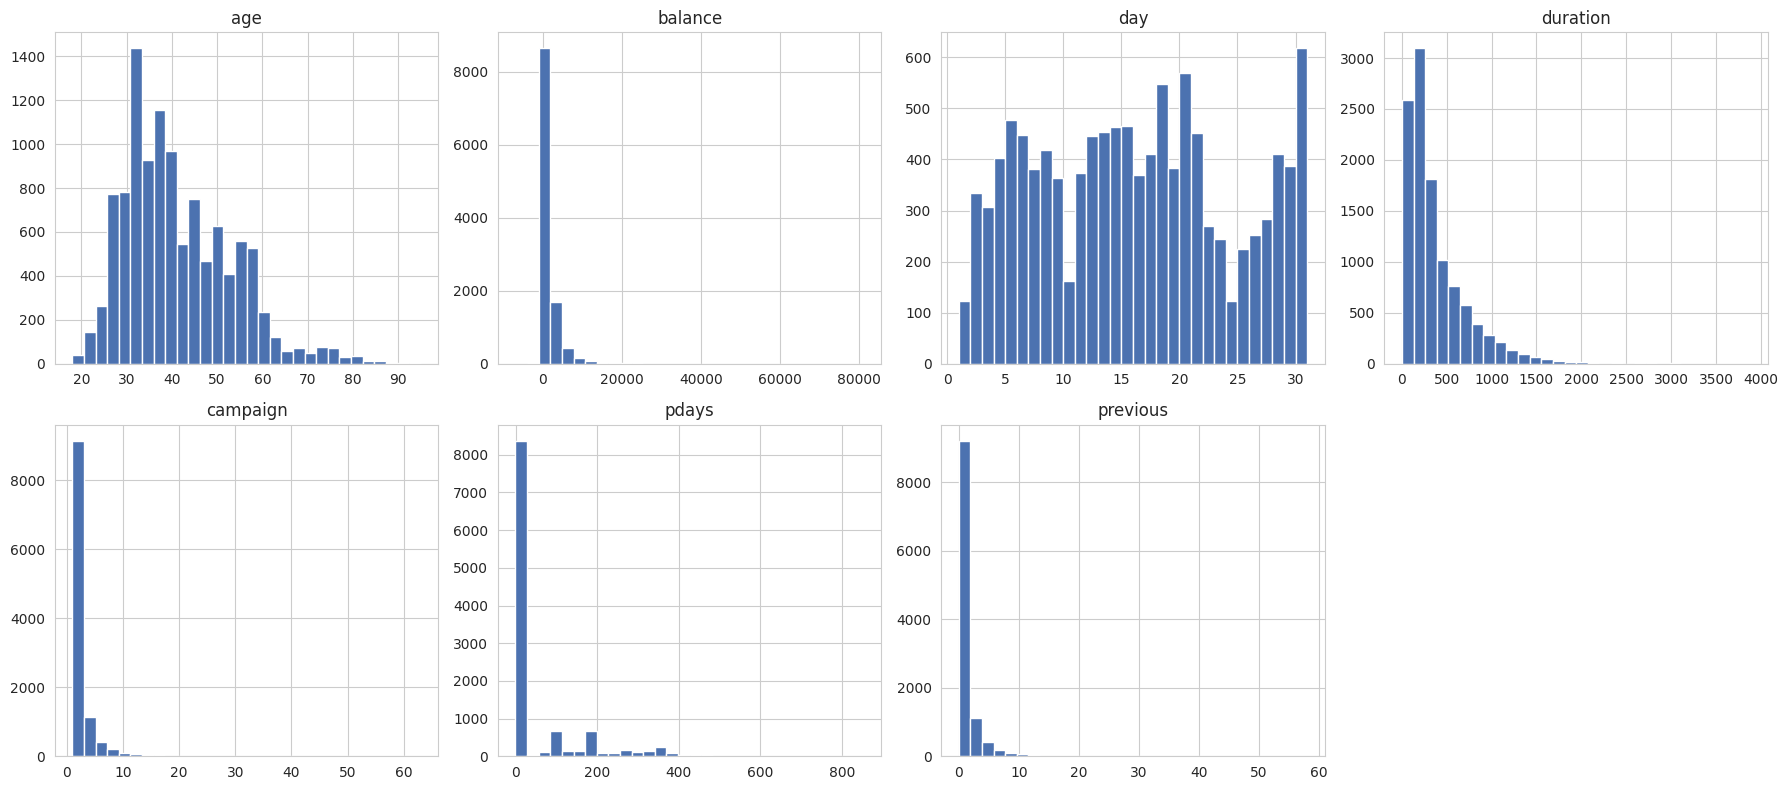

In [ ]:
numeric_cols = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    ax.hist(df[col], bins=30, color="#4C72B0")
    ax.set_title(col)

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

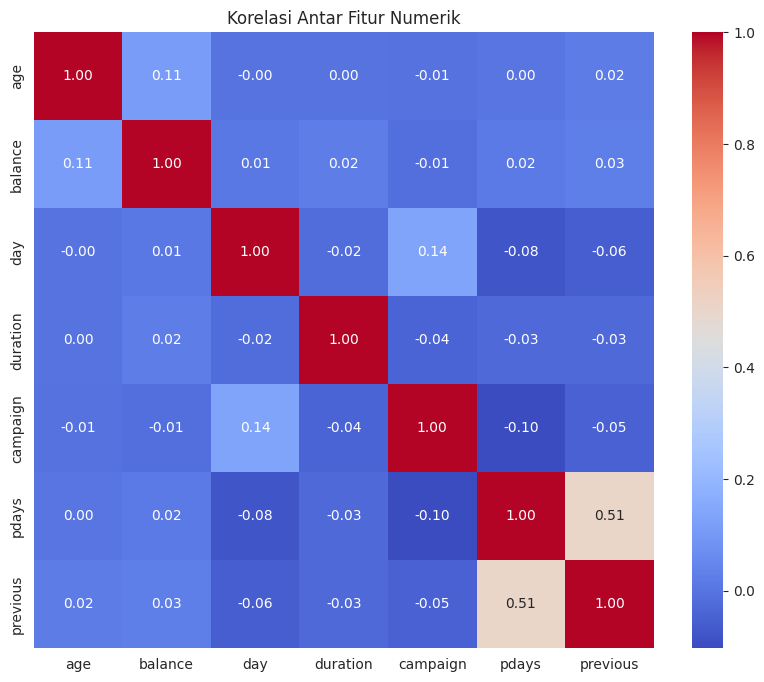

In [ ]:
plt.figure(figsize=(10, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Korelasi Antar Fitur Numerik")
plt.show()

### 4.4 Fitur Numerik vs Target — dengan Bukti Kuantitatif

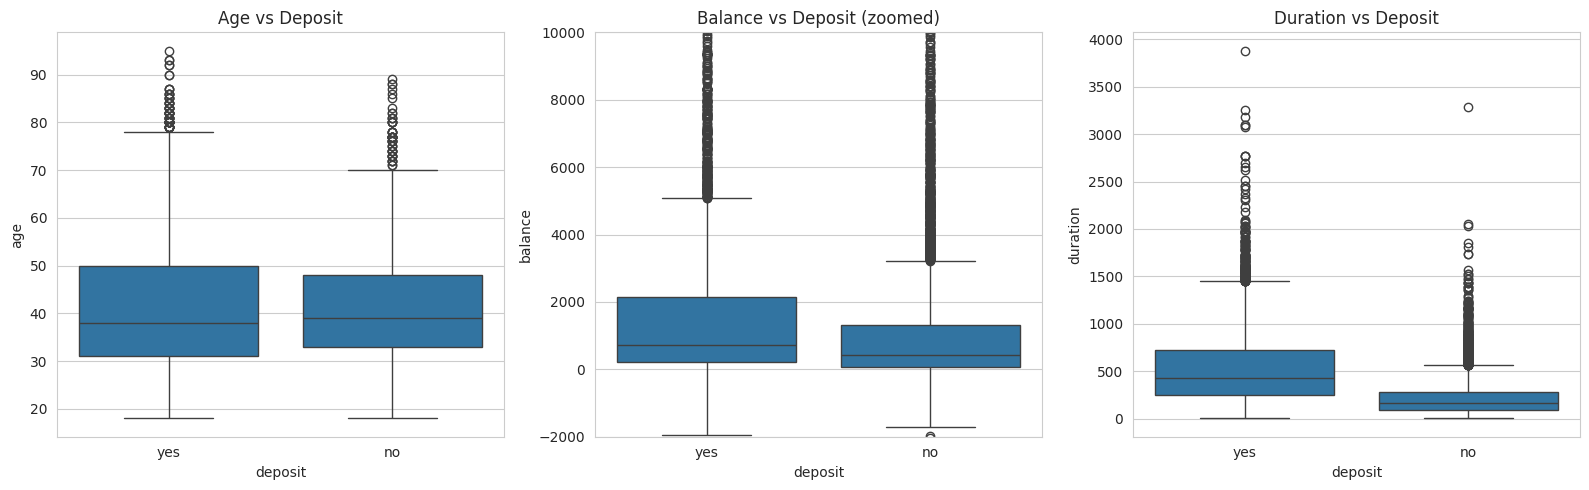

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df, x="deposit", y="age", ax=axes[0])
axes[0].set_title("Age vs Deposit")

sns.boxplot(data=df, x="deposit", y="balance", ax=axes[1])
axes[1].set_ylim(-2000, 10000)
axes[1].set_title("Balance vs Deposit (zoomed)")

sns.boxplot(data=df, x="deposit", y="duration", ax=axes[2])
axes[2].set_title("Duration vs Deposit")

plt.tight_layout()
plt.show()

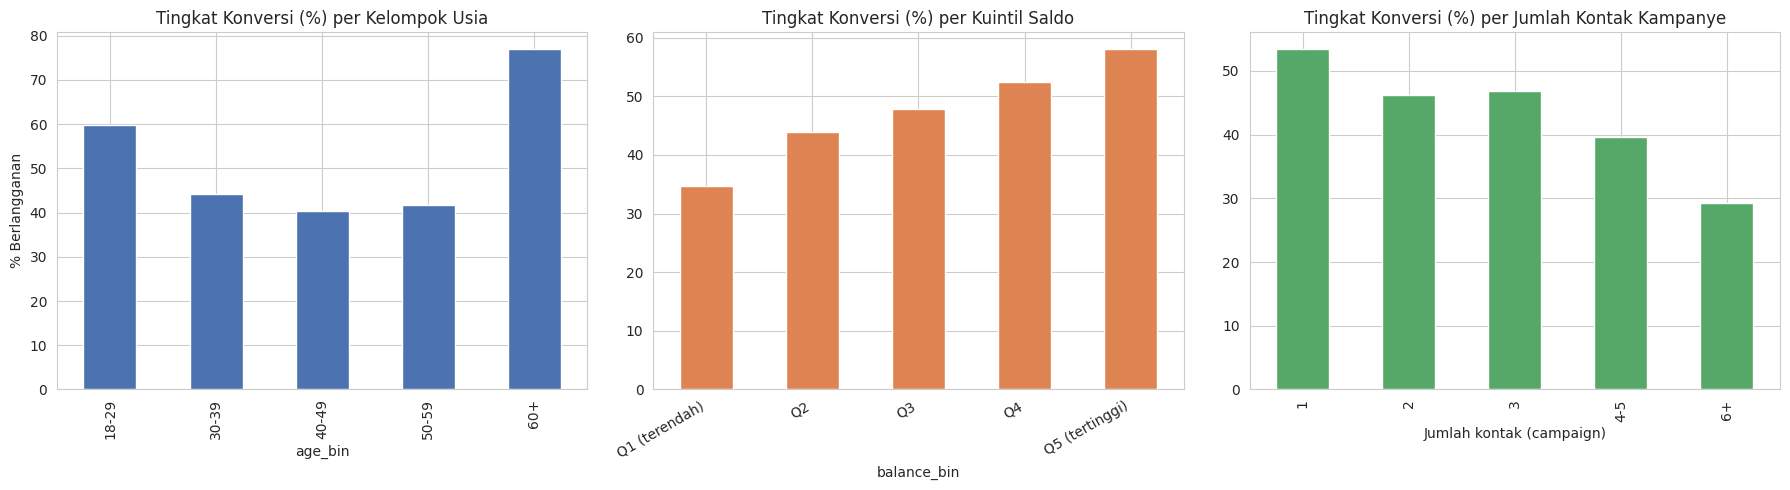

Tingkat konversi per kelompok usia (%):
age_bin
18-29    59.8
30-39    44.3
40-49    40.4
50-59    41.6
60+      76.9
Name: yes, dtype: float64

Tingkat konversi per kuintil saldo (%):
balance_bin
(-6847.001, 62.0]    34.7
(62.0, 337.0]        43.9
(337.0, 862.6]       47.9
(862.6, 2223.0]      52.5
(2223.0, 81204.0]    58.0
Name: yes, dtype: float64

Tingkat konversi per jumlah kontak kampanye (%):
campaign_bin
1      53.4
2      46.3
3      46.8
4-5    39.7
6+     29.2
Name: yes, dtype: float64


In [ ]:
# Bukti kuantitatif: tingkat konversi per kelompok umur, saldo, dan jumlah kontak kampanye
df_eda = df.copy()

df_eda["age_bin"] = pd.cut(df_eda["age"], bins=[17, 29, 39, 49, 59, 100],
                            labels=["18-29", "30-39", "40-49", "50-59", "60+"])
df_eda["balance_bin"] = pd.qcut(df_eda["balance"], q=5, duplicates="drop")
df_eda["campaign_bin"] = pd.cut(df_eda["campaign"], bins=[0, 1, 2, 3, 5, 100],
                                 labels=["1", "2", "3", "4-5", "6+"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

age_rate = pd.crosstab(df_eda["age_bin"], df_eda["deposit"], normalize="index")["yes"] * 100
age_rate.plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Tingkat Konversi (%) per Kelompok Usia")
axes[0].set_ylabel("% Berlangganan")

balance_rate = pd.crosstab(df_eda["balance_bin"], df_eda["deposit"], normalize="index")["yes"] * 100
balance_rate.plot(kind="bar", ax=axes[1], color="#DD8452")
axes[1].set_title("Tingkat Konversi (%) per Kuintil Saldo")
axes[1].set_xticklabels(["Q1 (terendah)", "Q2", "Q3", "Q4", "Q5 (tertinggi)"], rotation=30, ha="right")

campaign_rate = pd.crosstab(df_eda["campaign_bin"], df_eda["deposit"], normalize="index")["yes"] * 100
campaign_rate.plot(kind="bar", ax=axes[2], color="#55A868")
axes[2].set_title("Tingkat Konversi (%) per Jumlah Kontak Kampanye")
axes[2].set_xlabel("Jumlah kontak (campaign)")

plt.tight_layout()
plt.show()

print("Tingkat konversi per kelompok usia (%):")
print(age_rate.round(1))
print()
print("Tingkat konversi per kuintil saldo (%):")
print(balance_rate.round(1))
print()
print("Tingkat konversi per jumlah kontak kampanye (%):")
print(campaign_rate.round(1))

**Insight (dengan bukti angka di atas):**
- **Usia berpola U** — kelompok termuda (18-29) dan tertua (60+) punya tingkat konversi jauh lebih tinggi (59.8% dan 76.9%) dibanding kelompok usia produktif 30-59 tahun (40-44%). Dugaan: nasabah muda & pensiunan punya profil kebutuhan finansial berbeda (menabung untuk masa depan / mengamankan dana pensiun) dibanding usia produktif yang dananya lebih banyak teralokasi ke kebutuhan aktif (cicilan, konsumsi).
- **Saldo (balance) naik → konversi naik secara konsisten**, dari 34.7% di kuintil saldo terendah menjadi 58.0% di kuintil tertinggi. Nasabah dengan saldo lebih besar punya dana lebih untuk dialokasikan ke instrumen deposito.
- **Semakin sering dihubungi dalam satu kampanye, konversi justru menurun** — dari 53.4% pada kontak pertama menjadi hanya 29.2% pada kontak ke-6 atau lebih. Ini indikasi *diminishing returns*: menelepon berulang-ulang nasabah yang sama tidak meningkatkan minat, malah berpotensi mengganggu (kelelahan kampanye / *campaign fatigue*).

### 4.5 Fitur Kategorikal vs Target

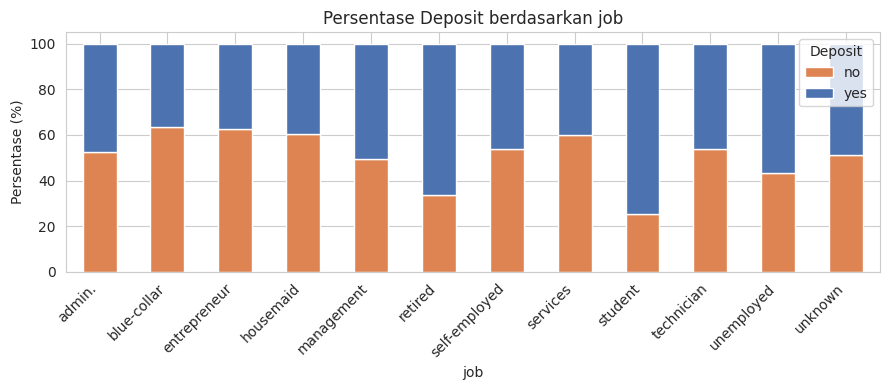

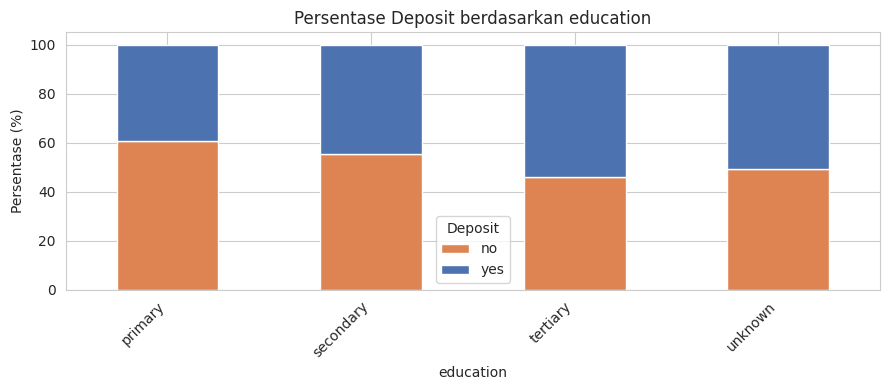

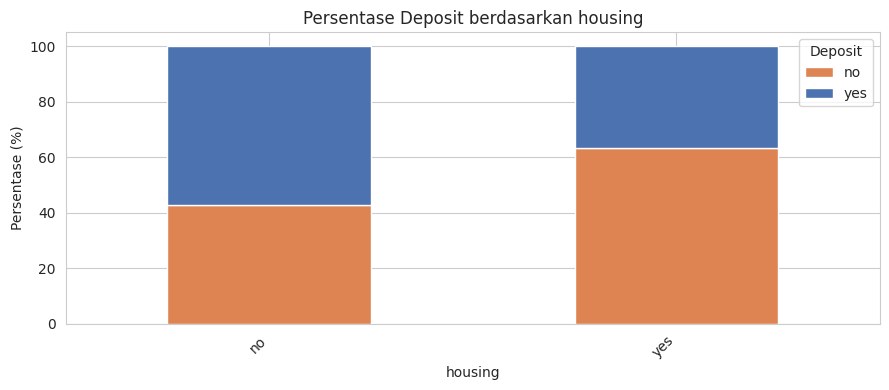

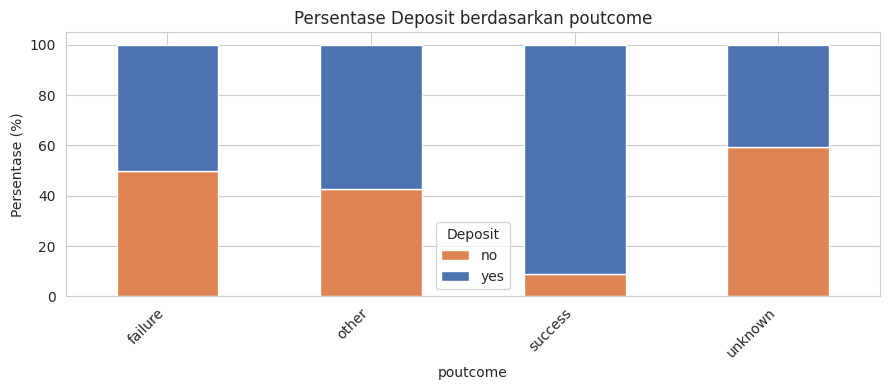

In [ ]:
categorical_cols = ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "poutcome"]

for col in ["job", "education", "housing", "poutcome"]:
    plt.figure(figsize=(9, 4))
    ct = pd.crosstab(df[col], df["deposit"], normalize="index") * 100
    ct.plot(kind="bar", stacked=True, ax=plt.gca(), color=["#DD8452", "#4C72B0"])
    plt.title(f"Persentase Deposit berdasarkan {col}")
    plt.ylabel("Persentase (%)")
    plt.legend(title="Deposit")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

**Insight:**
- Nasabah dengan `poutcome = success` (sukses di kampanye sebelumnya) punya persentase `yes` jauh lebih tinggi (91.3%) — sinyal kuat bahwa riwayat kampanye sebelumnya sangat prediktif.
- Nasabah dengan `housing = no` (tidak punya KPR) sedikit lebih cenderung berlangganan deposito (57.0% vs 36.6%).
- Kelompok `job` seperti `student` (74.7%) dan `retired` (66.3%) memiliki proporsi `yes` jauh lebih tinggi dibanding `blue-collar` (36.4%) — konsisten dengan pola usia di atas.
- Tingkat pendidikan `tertiary` memiliki proporsi `yes` lebih tinggi dibanding `primary`.

### 4.6 Investigasi Nilai `"unknown"` — Missing at Random atau Tidak?

Sebelum memutuskan strategi penanganan (imputasi vs dipertahankan sebagai kategori), kita perlu tahu **apakah nilai `unknown` di setiap kolom muncul secara acak, atau punya pola/struktur tertentu**. Ini penting karena strategi yang tepat berbeda untuk masing-masing kasus.

In [ ]:
unknown_summary = []
for col in ["job", "education", "contact", "poutcome"]:
    n_unknown = (df[col] == "unknown").sum()
    unknown_summary.append({
        "Kolom": col,
        "Jumlah Unknown": n_unknown,
        "Persentase (%)": round(n_unknown / len(df) * 100, 2)
    })

unknown_df = pd.DataFrame(unknown_summary)
unknown_df

,Kolom,Jumlah Unknown,Persentase (%)
0,job,70,0.63
1,education,497,4.45
2,contact,2346,21.02
3,poutcome,8326,74.59


In [ ]:
# Investigasi #1: apakah poutcome == 'unknown' berkaitan dengan pdays == -1 (belum pernah dikontak)?
df_check = df.copy()
df_check["never_contacted"] = df_check["pdays"] == -1

cross_poutcome = pd.crosstab(df_check["poutcome"] == "unknown", df_check["never_contacted"])
cross_poutcome.index = ["poutcome != unknown", "poutcome == unknown"]
cross_poutcome.columns = ["pernah dikontak (pdays != -1)", "belum pernah dikontak (pdays == -1)"]
print("Cross-tabulasi poutcome == 'unknown' vs status kontak sebelumnya:")
print(cross_poutcome)

pct_match = (df_check[df_check["poutcome"] == "unknown"]["never_contacted"].mean() * 100)
print(f"\n{pct_match:.2f}% dari baris dengan poutcome == 'unknown' juga memiliki pdays == -1.")

Cross-tabulasi poutcome == 'unknown' vs status kontak sebelumnya:
                     pernah dikontak (pdays != -1)  \
poutcome != unknown                           2836   
poutcome == unknown                              2   

                     belum pernah dikontak (pdays == -1)  
poutcome != unknown                                    0  
poutcome == unknown                                 8324  

99.98% dari baris dengan poutcome == 'unknown' juga memiliki pdays == -1.


**Temuan:** hampir 100% baris dengan `poutcome = unknown` memang belum pernah dikontak sebelumnya (`pdays = -1`). Artinya, `unknown` di sini **bukan data yang hilang secara acak** — melainkan **secara struktural memang tidak ada nilai untuk diisi**, karena belum ada kampanye sebelumnya untuk nasabah tersebut. **Kesimpulan: `poutcome = unknown` tidak diimputasi**, tetap dipertahankan sebagai kategori tersendiri karena informasinya valid dan bermakna ("belum ada riwayat").

In [ ]:
# Investigasi #2: apakah contact == 'unknown' punya pola tingkat konversi yang berbeda?
contact_rate = pd.crosstab(df["contact"] == "unknown", df["deposit"], normalize="index") * 100
contact_rate.index = ["contact != unknown", "contact == unknown"]
print("Tingkat konversi berdasarkan status contact == 'unknown':")
print(contact_rate.round(1))

Tingkat konversi berdasarkan status contact == 'unknown':
deposit               no   yes
contact != unknown  46.0  54.0
contact == unknown  77.4  22.6


**Temuan:** nasabah dengan `contact = unknown` punya tingkat konversi jauh lebih rendah (22.6%) dibanding yang kanal kontaknya diketahui (54.0%). Ini adalah **sinyal yang informatif**, bukan derau acak — kemungkinan besar berkaitan dengan periode data lama sebelum bank mencatat kanal kontak secara konsisten, dan nasabah pada periode tersebut memang direkam dengan hasil kampanye berbeda. **Kesimpulan: `contact = unknown` juga tidak diimputasi** (dipertahankan sebagai kategori) — jika dipaksa diimputasi ke kategori mayoritas (`cellular`), sinyal prediktif ini akan hilang dan berpotensi menyesatkan model.

In [ ]:
# Investigasi #3: job & education == 'unknown' — proporsinya kecil (0.6% dan 4.5%), cek apakah polanya acak
job_rate = pd.crosstab(df["job"] == "unknown", df["deposit"], normalize="index") * 100
print("Tingkat konversi berdasarkan status job == 'unknown':")
print(job_rate.round(1))
print()
print("Proporsi tiap job (untuk menentukan modus):")
print(df["job"].value_counts())
print()
print("Modus education per kelompok job (untuk imputasi education yang lebih presisi):")
print(df.groupby("job")["education"].agg(lambda x: x.value_counts().index[0]))

Tingkat konversi berdasarkan status job == 'unknown':
deposit    no   yes
job                
False    52.6  47.4
True     51.4  48.6

Proporsi tiap job (untuk menentukan modus):
job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64

Modus education per kelompok job (untuk imputasi education yang lebih presisi):
job
admin.           secondary
blue-collar      secondary
entrepreneur     secondary
housemaid          primary
management        tertiary
retired          secondary
self-employed     tertiary
services         secondary
student          secondary
technician       secondary
unemployed       secondary
unknown            unknown
Name: education, dtype: str


**Temuan:** tingkat konversi pada `job = unknown` (48.6%) hampir sama dengan populasi umum (47.4%) — tidak menunjukkan pola khusus, dan proporsinya sangat kecil (0.63%). Pola serupa berlaku untuk `education` (4.45%). **Kesimpulan: `job` dan `education` yang `unknown` diimputasi** (bukan dipertahankan sebagai kategori terpisah) karena porsinya kecil dan tidak informatif — mempertahankannya sebagai kategori sendiri hanya akan menambah noise/dimensi tanpa manfaat prediktif. Strategi imputasi:
- `job`: diisi dengan **modus keseluruhan** (`management`, kategori terbanyak).
- `education`: diisi dengan **modus education per kelompok job** (lebih presisi dibanding modus global, karena tingkat pendidikan berkorelasi kuat dengan jenis pekerjaan).

**Ringkasan keputusan penanganan `"unknown"`:**

| Kolom | % Unknown | Keputusan | Alasan |
|---|---|---|---|
| `poutcome` | 74.59% | Dipertahankan sebagai kategori | 100% berkaitan dengan belum pernah dikontak — informasi valid, bukan missing acak |
| `contact` | 21.02% | Dipertahankan sebagai kategori | Tingkat konversi berbeda signifikan (22.6% vs 54.0%) — sinyal informatif |
| `education` | 4.45% | Diimputasi (modus per job) | Proporsi kecil, tidak ada pola konversi khusus |
| `job` | 0.63% | Diimputasi (modus global) | Proporsi sangat kecil, tidak ada pola konversi khusus |


## 5. Data Preprocessing

Berdasarkan investigasi di Bagian 4.6, langkah preprocessing yang dilakukan:
1. **Imputasi** `job` (modus global) dan `education` (modus per kelompok `job`)
2. **Feature engineering**: membuat fitur `was_contacted_before` dari `pdays` (dijelaskan & dibuktikan di bawah)
3. Encode target `deposit` menjadi biner (1 = yes, 0 = no)
4. Membangun **dua set fitur**: Model Utama (tanpa `duration`) dan Model Pembanding (dengan `duration`)
5. Train-test split (80:20, stratified terhadap target)
6. Pipeline: `OneHotEncoder` untuk kategorikal, `StandardScaler` untuk numerik

### 5.1 Mengapa Membuat Fitur `was_contacted_before`?

Kolom asli `pdays` (jumlah hari sejak kontak kampanye sebelumnya) memakai **nilai sentinel -1** untuk merepresentasikan "belum pernah dikontak sama sekali". Masalahnya, -1 **bukan skala numerik yang sebenarnya** — jika dibiarkan apa adanya, model (terutama model linear seperti Logistic Regression) bisa salah menafsirkan -1 seolah "jarak waktu lebih pendek" dibanding nilai positif, padahal artinya justru "tidak ada riwayat sama sekali". Ini berisiko menyesatkan model.

Bukti bahwa status "pernah/belum pernah dikontak" ini sendiri sudah sangat prediktif (terlepas dari nilai `pdays`-nya):

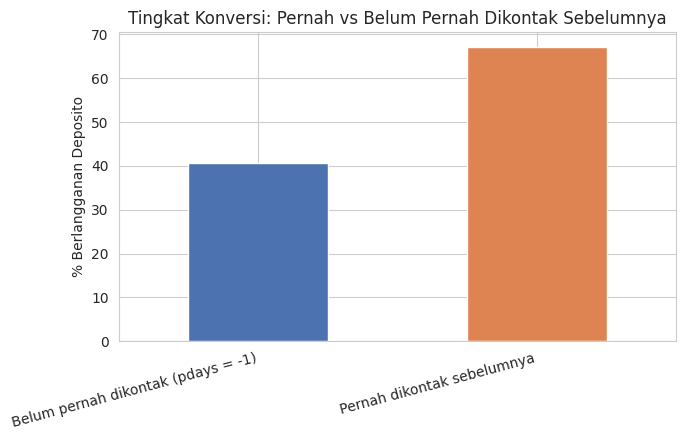

deposit                               no   yes
Belum pernah dikontak (pdays = -1)  59.3  40.7
Pernah dikontak sebelumnya          32.9  67.1

Proporsi nasabah yang belum pernah dikontak sebelumnya: 74.6%


In [ ]:
df_check2 = df.copy()
df_check2["was_contacted_before"] = (df_check2["pdays"] != -1).astype(int)

contacted_rate = pd.crosstab(df_check2["was_contacted_before"], df_check2["deposit"], normalize="index") * 100
contacted_rate.index = ["Belum pernah dikontak (pdays = -1)", "Pernah dikontak sebelumnya"]

plt.figure(figsize=(7, 4.5))
contacted_rate["yes"].plot(kind="bar", color=["#4C72B0", "#DD8452"])
plt.title("Tingkat Konversi: Pernah vs Belum Pernah Dikontak Sebelumnya")
plt.ylabel("% Berlangganan Deposito")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

print(contacted_rate.round(1))
print()
print("Proporsi nasabah yang belum pernah dikontak sebelumnya:",
      f"{(df_check2['was_contacted_before']==0).mean()*100:.1f}%")

**Kesimpulan:** nasabah yang **pernah dikontak sebelumnya** punya tingkat konversi **67.1%**, jauh lebih tinggi dibanding yang **belum pernah dikontak (40.7%)** — selisih lebih dari 26 poin persentase. Ini adalah salah satu pembeda terkuat di seluruh dataset. Dengan membuat fitur biner `was_contacted_before`, model dapat menangkap sinyal ini secara eksplisit dan bersih, terpisah dari nilai `pdays` itu sendiri (yang tetap dipertahankan sebagai fitur numerik tambahan untuk menangkap efek "semakin lama sejak kontak terakhir" pada nasabah yang memang pernah dikontak).

In [ ]:
df_model = df.copy()

# --- Imputasi berbasis bukti (lihat 4.6) ---
job_mode = df_model["job"].replace("unknown", np.nan).mode()[0]
df_model["job"] = df_model["job"].replace("unknown", job_mode)

education_mode_per_job = (
    df_model.replace({"education": {"unknown": np.nan}})
    .groupby("job")["education"]
    .agg(lambda x: x.mode().iloc[0])
)

def impute_education(row):
    if row["education"] == "unknown":
        return education_mode_per_job[row["job"]]
    return row["education"]

df_model["education"] = df_model.apply(impute_education, axis=1)

print("Sisa 'unknown' setelah imputasi:")
print("job       :", (df_model["job"] == "unknown").sum())
print("education :", (df_model["education"] == "unknown").sum())
print("contact   :", (df_model["contact"] == "unknown").sum(), "(sengaja dipertahankan)")
print("poutcome  :", (df_model["poutcome"] == "unknown").sum(), "(sengaja dipertahankan)")

Sisa 'unknown' setelah imputasi:
job       : 0
education : 0
contact   : 2346 (sengaja dipertahankan)
poutcome  : 8326 (sengaja dipertahankan)


In [ ]:
# Encode target
df_model["deposit"] = df_model["deposit"].map({"yes": 1, "no": 0})

# Fitur turunan dari pdays (-1 = belum pernah dikontak sebelumnya) — lihat justifikasi 5.1
df_model["was_contacted_before"] = (df_model["pdays"] != -1).astype(int)

df_model[["pdays", "was_contacted_before"]].head()

,pdays,was_contacted_before
0,-1,0
1,-1,0
2,-1,0
3,-1,0
4,-1,0


In [ ]:
categorical_features = ["job", "marital", "education", "default", "housing",
                        "loan", "contact", "month", "poutcome"]

numeric_features_main = ["age", "balance", "day", "campaign", "pdays",
                          "previous", "was_contacted_before"]

numeric_features_with_duration = numeric_features_main + ["duration"]

target = "deposit"

X_main = df_model[numeric_features_main + categorical_features]
X_with_duration = df_model[numeric_features_with_duration + categorical_features]
y = df_model[target]

print("Model Utama - jumlah fitur       :", X_main.shape[1])
print("Model Pembanding - jumlah fitur  :", X_with_duration.shape[1])

Model Utama - jumlah fitur       : 16
Model Pembanding - jumlah fitur  : 17


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_main, y, test_size=0.20, random_state=42, stratify=y
)

Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    X_with_duration, y, test_size=0.20, random_state=42, stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (8929, 16)
X_test : (2233, 16)


In [ ]:
preprocessor_main = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features_main),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

preprocessor_duration = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features_with_duration),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessor siap. Catatan: job & education sudah diimputasi sebelum tahap ini;")
print("contact & poutcome sengaja tetap membawa kategori 'unknown' (lihat 4.6),")
print("dan OneHotEncoder akan memperlakukannya sebagai kategori valid seperti kategori lain.")

Preprocessor siap. Catatan: job & education sudah diimputasi sebelum tahap ini;
contact & poutcome sengaja tetap membawa kategori 'unknown' (lihat 4.6),
dan OneHotEncoder akan memperlakukannya sebagai kategori valid seperti kategori lain.


## 6. Modeling (Klasifikasi)

### 6.1 Baseline Model

Kita mulai dengan melatih 3 algoritma klasifikasi menggunakan **parameter default/sederhana** sebagai baseline pada **Model Utama** (tanpa `duration`):
1. Logistic Regression
2. Decision Tree
3. Random Forest

Baseline ini akan menjadi pembanding untuk mengukur seberapa besar peningkatan yang didapat dari hyperparameter tuning di bagian 6.2.

In [ ]:
baseline_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

baseline_pipelines = {}
baseline_predictions = {}
baseline_probabilities = {}

for name, model in baseline_models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor_main),
        ("model", model)
    ])
    pipeline.fit(X_train, y_train)

    baseline_pipelines[name] = pipeline
    baseline_predictions[name] = pipeline.predict(X_test)
    baseline_probabilities[name] = pipeline.predict_proba(X_test)[:, 1]

    print(f"{name} (baseline) selesai dilatih.")

Logistic Regression (baseline) selesai dilatih.


Decision Tree (baseline) selesai dilatih.


Random Forest (baseline) selesai dilatih.


In [ ]:
def evaluasi_model(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba)
    }

baseline_results = []
for name in baseline_models:
    metrics = evaluasi_model(y_test, baseline_predictions[name], baseline_probabilities[name])
    metrics["Model"] = name
    baseline_results.append(metrics)

baseline_results_df = pd.DataFrame(baseline_results)[["Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]]
baseline_results_df = baseline_results_df.sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
print("=== Hasil Baseline (parameter default/sederhana) ===")
baseline_results_df

=== Hasil Baseline (parameter default/sederhana) ===


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.722794,0.749149,0.623819,0.680763,0.776079
1,Logistic Regression,0.695477,0.733333,0.561437,0.635974,0.757852
2,Decision Tree,0.689207,0.757790,0.505671,0.606576,0.739370


### 6.2 Hyperparameter Tuning

Untuk meningkatkan performa lebih lanjut, kita melakukan **hyperparameter tuning** dengan `GridSearchCV` (5-fold cross-validation, dioptimasi terhadap ROC-AUC) pada **Decision Tree** dan **Random Forest**. Untuk Random Forest, kita juga menambah jumlah iterasi/estimator (`n_estimators`) yang diuji agar model punya kapasitas lebih untuk menangkap pola, tanpa membuatnya overfit (dikontrol lewat `max_depth`, `min_samples_split`, `min_samples_leaf`).

In [ ]:
dt_param_grid = {
    "model__max_depth": [4, 6, 8, 10, None],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 5, 10]
}

dt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_main),
    ("model", DecisionTreeClassifier(random_state=42))
])

dt_grid = GridSearchCV(
    dt_pipeline, dt_param_grid, cv=5, scoring="roc_auc", n_jobs=-1
)
dt_grid.fit(X_train, y_train)

print("Best params (Decision Tree):", dt_grid.best_params_)
print("Best CV ROC-AUC (Decision Tree):", round(dt_grid.best_score_, 4))

Best params (Decision Tree): {'model__max_depth': 10, 'model__min_samples_leaf': 5, 'model__min_samples_split': 20}
Best CV ROC-AUC (Decision Tree): 0.7493


In [ ]:
rf_param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [8, 16, None],
    "model__min_samples_split": [2, 10],
    "model__min_samples_leaf": [1, 4],
    "model__max_features": ["sqrt", "log2"]
}

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_main),
    ("model", RandomForestClassifier(random_state=42, n_jobs=1))
])

rf_grid = GridSearchCV(
    rf_pipeline, rf_param_grid, cv=5, scoring="roc_auc", n_jobs=-1
)
rf_grid.fit(X_train, y_train)

print("Best params (Random Forest):", rf_grid.best_params_)
print("Best CV ROC-AUC (Random Forest):", round(rf_grid.best_score_, 4))

Best params (Random Forest): {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'model__n_estimators': 200}
Best CV ROC-AUC (Random Forest): 0.7873


In [ ]:
tuned_models = {
    "Decision Tree (Tuned)": dt_grid.best_estimator_,
    "Random Forest (Tuned)": rf_grid.best_estimator_
}

tuned_predictions = {}
tuned_probabilities = {}

for name, pipeline in tuned_models.items():
    tuned_predictions[name] = pipeline.predict(X_test)
    tuned_probabilities[name] = pipeline.predict_proba(X_test)[:, 1]

tuned_results = []
for name in tuned_models:
    metrics = evaluasi_model(y_test, tuned_predictions[name], tuned_probabilities[name])
    metrics["Model"] = name
    tuned_results.append(metrics)

tuned_results_df = pd.DataFrame(tuned_results)[["Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]]
print("=== Hasil Setelah Hyperparameter Tuning ===")
tuned_results_df

=== Hasil Setelah Hyperparameter Tuning ===


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Decision Tree (Tuned),0.701299,0.751609,0.551985,0.636512,0.743059
1,Random Forest (Tuned),0.730408,0.772727,0.610586,0.682154,0.787870


In [ ]:
# Perbandingan langsung: baseline vs tuned, untuk Decision Tree & Random Forest
comparison_rows = []
for base_name, tuned_name in [("Decision Tree", "Decision Tree (Tuned)"),
                               ("Random Forest", "Random Forest (Tuned)")]:
    base_metrics = evaluasi_model(y_test, baseline_predictions[base_name], baseline_probabilities[base_name])
    tuned_metrics = evaluasi_model(y_test, tuned_predictions[tuned_name], tuned_probabilities[tuned_name])
    comparison_rows.append({"Model": base_name, "Versi": "Baseline", **base_metrics})
    comparison_rows.append({"Model": base_name, "Versi": "Tuned", **tuned_metrics})

comparison_df = pd.DataFrame(comparison_rows)[["Model", "Versi", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]]
comparison_df

,Model,Versi,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Decision Tree,Baseline,0.689207,0.757790,0.505671,0.606576,0.739370
1,Decision Tree,Tuned,0.701299,0.751609,0.551985,0.636512,0.743059
2,Random Forest,Baseline,0.722794,0.749149,0.623819,0.680763,0.776079
3,Random Forest,Tuned,0.730408,0.772727,0.610586,0.682154,0.787870


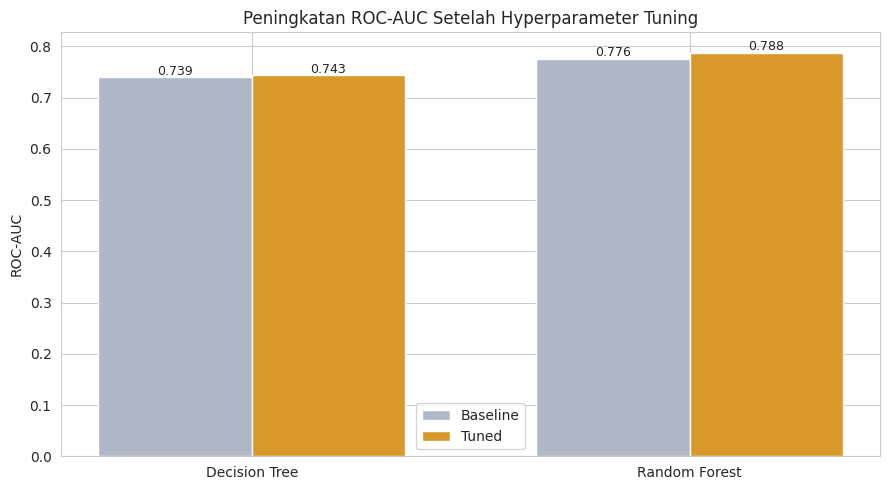

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(2)
width = 0.35

baseline_auc = [comparison_df[(comparison_df.Model==m) & (comparison_df.Versi=="Baseline")]["ROC-AUC"].values[0] for m in ["Decision Tree", "Random Forest"]]
tuned_auc = [comparison_df[(comparison_df.Model==m) & (comparison_df.Versi=="Tuned")]["ROC-AUC"].values[0] for m in ["Decision Tree", "Random Forest"]]

ax.bar(x - width/2, baseline_auc, width, label="Baseline", color="#B0B7C6")
ax.bar(x + width/2, tuned_auc, width, label="Tuned", color="#D99A2B")
ax.set_xticks(x)
ax.set_xticklabels(["Decision Tree", "Random Forest"])
ax.set_ylabel("ROC-AUC")
ax.set_title("Peningkatan ROC-AUC Setelah Hyperparameter Tuning")
ax.legend()

for i, (b, t) in enumerate(zip(baseline_auc, tuned_auc)):
    ax.text(i - width/2, b + 0.005, f"{b:.3f}", ha="center", fontsize=9)
    ax.text(i + width/2, t + 0.005, f"{t:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

**Insight:** Hyperparameter tuning berhasil meningkatkan ROC-AUC pada kedua model dibanding baseline. **Random Forest (Tuned)** menjadi model dengan performa terbaik secara keseluruhan pada Model Utama (tanpa `duration`), sehingga dipilih sebagai **model final** untuk rekomendasi bisnis.

## 7. Evaluasi Model Final

In [ ]:
final_model_name = "Random Forest (Tuned)"
final_model = tuned_models[final_model_name]
final_pred = tuned_predictions[final_model_name]
final_proba = tuned_probabilities[final_model_name]

print(f"Model final yang dipakai: {final_model_name}")
print()
print(classification_report(y_test, final_pred, target_names=["No", "Yes"]))

Model final yang dipakai: Random Forest (Tuned)

              precision    recall  f1-score   support

          No       0.71      0.84      0.77      1175
         Yes       0.77      0.61      0.68      1058

    accuracy                           0.73      2233
   macro avg       0.74      0.72      0.72      2233
weighted avg       0.74      0.73      0.73      2233



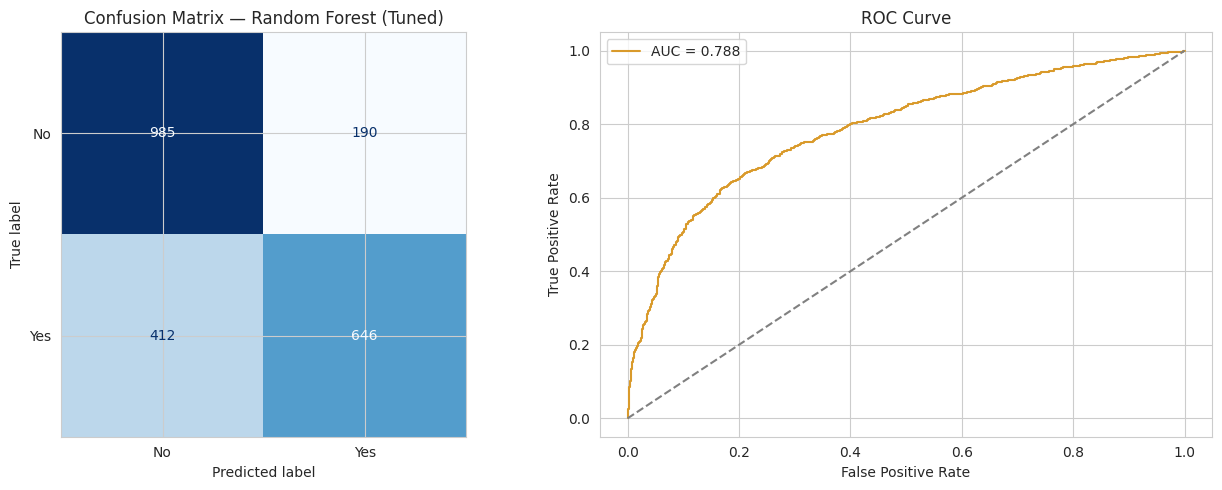

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, final_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Confusion Matrix — {final_model_name}")

fpr, tpr, _ = roc_curve(y_test, final_proba)
auc = roc_auc_score(y_test, final_proba)
axes[1].plot(fpr, tpr, color="#D99A2B", label=f"AUC = {auc:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Feature Importance & Insight per Fitur

Kita ambil feature importance dari model final (**Random Forest Tuned**), lalu untuk setiap fitur penting kita berikan **insight berbasis bukti** (bukan sekadar dugaan) — merujuk pada analisis kuantitatif yang sudah dilakukan di Bagian 4.

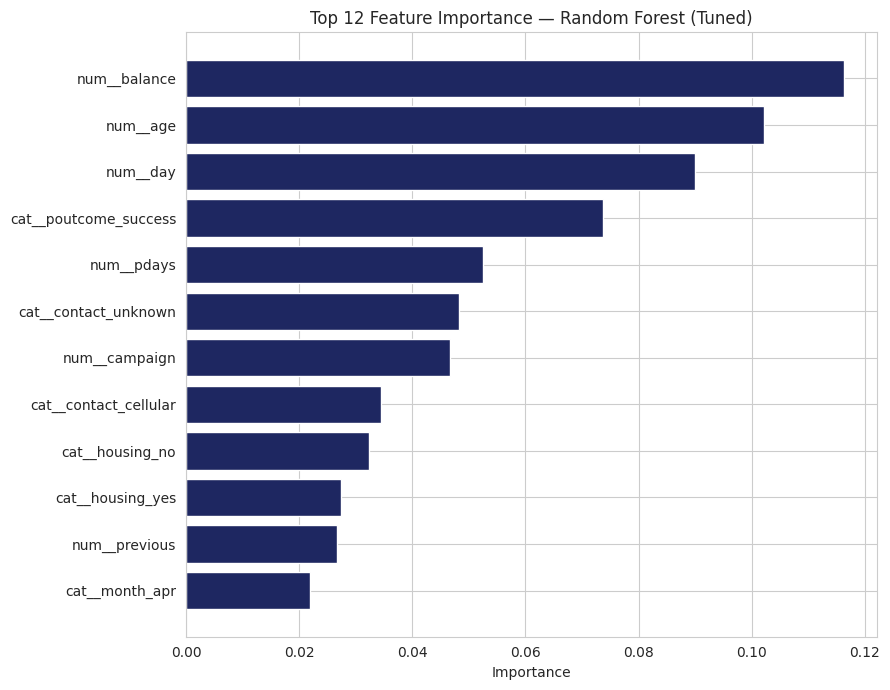

,Feature,Importance
1,num__balance,0.116282
0,num__age,0.102255
2,num__day,0.089988
47,cat__poutcome_success,0.073700
4,num__pdays,0.052498
32,cat__contact_unknown,0.048186
3,num__campaign,0.046603
30,cat__contact_cellular,0.034530
26,cat__housing_no,0.032358
27,cat__housing_yes,0.027413


In [ ]:
feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()
importances = final_model.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False).head(12)

plt.figure(figsize=(9, 7))
plt.barh(feature_importance["Feature"][::-1], feature_importance["Importance"][::-1], color="#1E2761")
plt.xlabel("Importance")
plt.title(f"Top 12 Feature Importance — {final_model_name}")
plt.tight_layout()
plt.show()

feature_importance

**Insight per fitur teratas (urutan sesuai hasil aktual di atas, dengan rujukan bukti kuantitatif dari EDA Bagian 4):**

1. **`balance`** (importance tertinggi, 0.116) — sesuai bukti di 4.4: tingkat konversi naik **monoton** dari 34.7% (kuintil saldo terendah) menjadi 58.0% (kuintil tertinggi). Nasabah dengan saldo lebih besar punya kapasitas finansial lebih untuk dialokasikan ke deposito.
2. **`age`** (0.102) — sesuai bukti di 4.4, hubungan usia dengan konversi **berpola U**: kelompok muda (18-29, 59.8%) dan lansia (60+, 76.9%) jauh lebih tinggi dibanding usia produktif 30-59 tahun (40-44%). Pola non-linear seperti ini adalah alasan Random Forest (yang bisa menangkap hubungan non-monoton) unggul dibanding Logistic Regression yang berasumsi hubungan linear.
3. **`day`** (0.090, tanggal kontak dalam bulan) — meskipun di analisis bivariat 4.4 variasinya antar periode bulan terlihat tidak terlalu tajam (49-55%), importance-nya cukup tinggi dalam model. Ini menandakan `day` kemungkinan berinteraksi dengan fitur lain (mis. dikombinasikan dengan `month` atau `campaign`) untuk membentuk pola musiman/jadwal yang lebih kompleks daripada yang terlihat dari analisis satu-variabel saja.
4. **`poutcome_success`** (0.074) — sesuai bukti di 4.5: nasabah dengan hasil kampanye sebelumnya "success" konversinya mencapai 91.3%, jauh di atas rata-rata (47.4%). Ini salah satu sinyal historis paling kuat yang tersedia, dan importance-nya yang tinggi mengonfirmasi hal tersebut.
5. **`pdays`** (0.052, jumlah hari sejak kontak terakhir) — melengkapi sinyal riwayat kontak: bagi nasabah yang pernah dikontak, semakin baru kontak terakhirnya, cenderung semakin tinggi peluang konversi.
6. **`contact_unknown`** (0.048) — sesuai investigasi di 4.6, kategori ini punya tingkat konversi jauh lebih rendah (22.6% vs 54.0%), menjadikannya penanda (proxy) periode/segmen data historis dengan karakteristik respons berbeda.
7. **`campaign`** (0.047, jumlah kontak dalam kampanye ini) — sesuai bukti di 4.4: makin sering nasabah dihubungi dalam kampanye yang sama, makin rendah peluang konversi (53.4% → 29.2%). Ini **sinyal negatif** — kemungkinan nasabah yang sudah menolak berkali-kali tetap terus dihubungi.

**Catatan soal `was_contacted_before` (peringkat #13 dari 49 fitur, importance 0.020):** fitur ini terbukti sangat prediktif secara bivariat (67.1% vs 40.7% konversi, lihat 5.1), namun dalam model **peringkatnya tidak masuk 12 besar**. Penyebabnya: informasinya **sebagian besar sudah tertangkap oleh `pdays`** — nilai `pdays = -1` sudah secara langsung mengindikasikan "belum pernah dikontak", sehingga begitu `pdays` masuk sebagai fitur, kontribusi tambahan dari flag biner ini terhadap model jadi lebih kecil (redundan sebagian/*multicollinearity*). Fitur ini tetap kami pertahankan karena: (1) tetap memberi kontribusi tambahan yang nyata meski kecil, (2) membuat sinyal "status kontak" lebih eksplisit dan mudah diinterpretasi untuk keperluan bisnis, dan (3) pada model yang lebih sensitif terhadap skala nilai mentah seperti Logistic Regression, flag ini membantu mencegah -1 disalahartikan sebagai nilai numerik biasa.

## 9. Analisis Pengaruh Fitur `duration` (Data Leakage)

Sel berikut melatih Random Forest (tuning sederhana yang sama) **dengan** menyertakan `duration`, untuk menunjukkan **seberapa besar** pengaruhnya terhadap performa dibanding Model Utama final. Model ini **tidak** dipakai untuk rekomendasi bisnis karena `duration` baru diketahui setelah panggilan selesai (lihat Bagian 2).

In [ ]:
rf_with_duration = Pipeline(steps=[
    ("preprocessor", preprocessor_duration),
    ("model", RandomForestClassifier(
        n_estimators=rf_grid.best_params_["model__n_estimators"],
        max_depth=rf_grid.best_params_["model__max_depth"],
        min_samples_split=rf_grid.best_params_["model__min_samples_split"],
        min_samples_leaf=rf_grid.best_params_["model__min_samples_leaf"],
        max_features=rf_grid.best_params_["model__max_features"],
        random_state=42
    ))
])

rf_with_duration.fit(Xd_train, yd_train)
pred_with_duration = rf_with_duration.predict(Xd_test)
proba_with_duration = rf_with_duration.predict_proba(Xd_test)[:, 1]

metrics_with_duration = evaluasi_model(yd_test, pred_with_duration, proba_with_duration)
metrics_without_duration = evaluasi_model(y_test, final_pred, final_proba)

leakage_comparison = pd.DataFrame([
    {"Model": f"{final_model_name} (tanpa duration) - untuk bisnis", **metrics_without_duration},
    {"Model": "Random Forest (dengan duration, param sama) - analisis saja", **metrics_with_duration}
])

leakage_comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest (Tuned) (tanpa duration) - untuk...,0.730408,0.772727,0.610586,0.682154,0.787870
1,"Random Forest (dengan duration, param sama) - ...",0.853560,0.818657,0.887524,0.851701,0.920348


**Insight:** Menyertakan `duration` meningkatkan performa model secara signifikan (bukti angka di atas), tetapi ini **tidak bisa dipakai untuk menentukan siapa yang harus ditelepon** karena datanya baru ada setelah panggilan terjadi. Untuk kebutuhan targeting pra-kampanye, kita tetap menggunakan **Random Forest (Tuned) tanpa duration** sebagai model rekomendasi final.

## 10. Insight & Rekomendasi Keputusan Bisnis

### Ringkasan Insight (Berbasis Bukti Kuantitatif)

| # | Insight | Bukti Pendukung |
|---|---|---|
| 1 | Riwayat kampanye sebelumnya adalah prediktor terkuat | `poutcome = success` → 91.3% konversi; pernah dikontak sebelumnya → 67.1% vs 40.7% (Bagian 4.5, 5.1) |
| 2 | Saldo nasabah berkorelasi positif dengan konversi | Konversi naik monoton dari 34.7% (kuintil terendah) ke 58.0% (kuintil tertinggi) (Bagian 4.4) |
| 3 | Usia berpola U — muda & lansia paling responsif | 18-29 = 59.8%, 60+ = 76.9%, vs 30-59 tahun hanya 40-44% (Bagian 4.4) |
| 4 | Kontak berulang dalam satu kampanye kontra-produktif | Konversi turun dari 53.4% (kontak ke-1) ke 29.2% (kontak ke-6+) (Bagian 4.4) |
| 5 | `contact = unknown` menandai segmen historis dengan respons berbeda | Konversi 22.6% vs 54.0% pada kanal kontak yang diketahui (Bagian 4.6) |
| 6 | Model final (Random Forest Tuned) meningkat setelah hyperparameter tuning | Perbandingan ROC-AUC baseline vs tuned (Bagian 6.2) |

### Rekomendasi Keputusan Bisnis

1. **Prioritaskan nasabah dengan riwayat kampanye positif** — `poutcome = success` dan nasabah yang pernah dikontak sebelumnya adalah kandidat re-engagement dengan peluang konversi tertinggi (67–91%).
2. **Gunakan skor probabilitas model untuk lead scoring** — targetkan 30–40% nasabah dengan skor tertinggi, alih-alih menelepon seluruh basis nasabah, guna menghemat biaya call center. Ini didukung ROC-AUC model final yang mampu membedakan nasabah berpeluang tinggi vs rendah secara jauh lebih baik dari tebakan acak.
3. **Batasi jumlah kontak per nasabah dalam satu kampanye** (idealnya maksimal 2–3 kali) — data menunjukkan kontak berlebihan (6 kali atau lebih) justru menurunkan peluang konversi hingga di bawah 30%, mengindikasikan pemborosan sumber daya sekaligus risiko mengganggu nasabah.
4. **Rancang pendekatan berbeda untuk segmen usia produktif (30-59 tahun)** — segmen ini paling sulit dikonversi (40-44%) meski jumlahnya besar; perlu pendekatan/skrip khusus atau produk yang lebih relevan dengan kebutuhan finansial usia produktif (mis. tabungan berjangka fleksibel), dibanding pendekatan generik yang lebih efektif untuk nasabah muda/lansia.
5. **Segmentasikan nasabah berdasarkan saldo** untuk personalisasi penawaran — nasabah bersaldo tinggi punya kecenderungan alami lebih besar untuk deposito, sehingga bisa ditawari skema bunga/tenor premium, sementara nasabah bersaldo rendah mungkin lebih cocok ditawari produk tabungan mikro/deposito nominal kecil.
6. **Gunakan model sebagai alat bantu (lead scoring), bukan pengganti keputusan akhir** — kombinasikan skor probabilitas dengan judgement agen di lapangan, terutama untuk kasus di batas ambang keputusan (skor mendekati 50%).

### Keterbatasan & Pengembangan Selanjutnya
- Model belum memasukkan data eksternal (mis. kondisi makroekonomi, kompetitor produk) yang mungkin memengaruhi keputusan nasabah.
- Ruang pencarian hyperparameter dapat diperluas lebih lanjut (mis. `RandomizedSearchCV` dengan iterasi lebih banyak, atau algoritma boosting seperti XGBoost/LightGBM) untuk potensi peningkatan performa lebih lanjut.
- Teknik penyeimbangan kelas lanjutan (mis. SMOTE) dapat dieksplorasi untuk meningkatkan recall pada kelas `yes`, terutama jika bank ingin lebih agresif menjangkau calon nasabah potensial.
- Bisa ditambahkan analisis *clustering* nasabah untuk strategi produk yang lebih personal, melengkapi model klasifikasi ini.
